# Brain Tumor MRI Classification - Part 3

**Author:** Kodanda Challa  
**Student ID:** 25727  
**Date:** 2026

## Project Overview

This notebook implements a **deep learning pipeline** for brain tumor classification using:

1. **Transfer Learning**: Pre-trained ResNet50 from ImageNet
2. **Explainability**: LIME (Local Interpretable Model-agnostic Explanations)

## Classification Task: 4-Class Brain Tumor Type

| Class | Type | Description |
|-------|------|-------------|
| **Glioma** | Brain tumor | Originates from glial cells |
| **Meningioma** | Membrane tumor | Tumor in protective membranes |
| **No Tumor** | Normal scan | Healthy brain tissue |
| **Pituitary** | Pituitary tumor | Tumor in pituitary gland |

## 1. Environment Setup & Imports

## Environment Setup and Library Imports

This section imports the core libraries used throughout the notebook:

- **TensorFlow/Keras** for deep learning and transfer learning
- **OpenCV** for image preprocessing
- **NumPy/Pandas** for numerical and tabular operations
- **Scikit-learn** for metrics and dataset utilities
- **Matplotlib/Seaborn** for visualization
- **LIME** for explainable AI

Transfer learning enables reuse of pretrained visual features learned on large datasets like ImageNet.

In [1]:
# ============================================================================
# SECTION 1: ENVIRONMENT SETUP
# Purpose: Import all required libraries and verify installation
# ============================================================================

import os
import time
import pickle
import warnings
import random
import cv2

# Data manipulation and analysis
import numpy as np
import pandas as pd
import imutils


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap

# Machine Learning - Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

# Deep Learning - TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# Explainability - LIME
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("="*70)
print("ENVIRONMENT SETUP")
print("="*70)
print("\n✓ All libraries imported successfully")
print(f"\nVersion Information:")
print(f"  TensorFlow: {tf.__version__}")
print(f"  NumPy: {np.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"\nHardware:")
print(f"  GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
if len(tf.config.list_physical_devices('GPU')) > 0:
    print(f"  GPU Name: {tf.config.list_physical_devices('GPU')[0].name}")

ENVIRONMENT SETUP

✓ All libraries imported successfully

Version Information:
  TensorFlow: 2.21.0
  NumPy: 2.4.5
  Pandas: 3.0.3

Hardware:
  GPU Available: False


## 2. Configuration & Hyperparameters

## Hyperparameter Configuration

Hyperparameters control model behaviour:

- **Image size** determines input resolution
- **Batch size** affects memory usage and gradient stability
- **Epochs** define training iterations
- **Learning rate** controls optimization step size

Choosing appropriate hyperparameters is critical for balancing convergence speed and generalization.

In [2]:
# ============================================================================
# SECTION 2: CONFIGURATION
# Purpose: Centralized configuration for easy modification
# ============================================================================

# Track overall program execution time
PROGRAM_START = time.perf_counter()

# ===== DATASET CONFIGURATION =====
# Define paths to training and testing data directories
DATASET_PATH = "Dataset_MRI"              # Root dataset directory
TRAIN_DIR = os.path.join(DATASET_PATH, 'Training')  # Training data path
TEST_DIR = os.path.join(DATASET_PATH, 'Testing')    # Testing data path

# Define class labels (must match directory names)
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASSES)

# ===== IMAGE PROCESSING CONFIGURATION =====
# ResNet50 expects 224x224 RGB images
IMG_SIZE = 224                            # Target image width and height (224x224 for ResNet50)
IMG_CHANNELS = 3                          # RGB images (3 channels)
SUPPORTED_FORMATS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp')  # Supported image formats

# ===== TRAINING HYPERPARAMETERS =====
BATCH_SIZE = 32                           # Number of samples per batch
EPOCHS = 20                               # Maximum number of epochs (EarlyStopping may reduce)
VALIDATION_SPLIT = 0.2                    # Use 20% of training data for validation
INITIAL_LEARNING_RATE = 0.001             # Starting learning rate for Adam optimizer

# ===== CALLBACK CONFIGURATION =====
# Early stopping prevents overfitting by stopping training when validation loss stops improving
EARLY_STOPPING_MONITOR = 'val_loss'       # Metric to monitor for early stopping
EARLY_STOPPING_PATIENCE = 3               # Number of epochs to wait before stopping

# Learning rate reduction reduces learning rate if validation loss plateaus
LR_REDUCTION_FACTOR = 0.3                 # Multiply learning rate by this factor
LR_REDUCTION_PATIENCE = 2                 # Epochs to wait before reducing learning rate
MIN_LEARNING_RATE = 1e-7                  # Minimum learning rate (prevent too small values)

# ===== MODEL CHECKPOINTING =====
BEST_MODEL_PATH = 'best_resnet50_model.h5'  # Save best model during training
LABEL_ENCODER_PATH = 'label_encoder.pkl'    # Save label encoder for later use
FINAL_MODEL_PATH = 'brain_tumor_classifier_resnet50.h5'  # Final model path

# ===== LIME CONFIGURATION =====
# LIME (Local Interpretable Model-agnostic Explanations) explains individual predictions
LIME_NUM_SAMPLES = 500                    # Number of perturbed samples to generate
LIME_NUM_FEATURES = 10                    # Number of top features to highlight

# ===== REPRODUCIBILITY SETTINGS =====
# Set random seeds to ensure reproducible results across runs
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ===== VISUALIZATION SETTINGS =====
# Configure matplotlib and seaborn for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("\n" + "="*70)
print("CONFIGURATION LOADED")
print("="*70)
print(f"\nDataset:")
print(f"  Path: {DATASET_PATH}")
print(f"  Classes: {NUM_CLASSES} - {', '.join(CLASSES)}")
print(f"\nImage Processing:")
print(f"  Size: {IMG_SIZE}×{IMG_SIZE}×{IMG_CHANNELS}")
print(f"  Supported Formats: {', '.join(SUPPORTED_FORMATS)}")
print(f"\nTraining:")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Max Epochs: {EPOCHS}")
print(f"  Learning Rate: {INITIAL_LEARNING_RATE}")
print(f"  Validation Split: {VALIDATION_SPLIT*100:.0f}%")


CONFIGURATION LOADED

Dataset:
  Path: Dataset_MRI
  Classes: 4 - glioma, meningioma, notumor, pituitary

Image Processing:
  Size: 224×224×3
  Supported Formats: .jpg, .jpeg, .png, .tif, .tiff, .bmp

Training:
  Batch Size: 32
  Max Epochs: 20
  Learning Rate: 0.001
  Validation Split: 20%


## 3. Data Loading & DataFrame Creation

## Dataset Construction

Images are indexed into structured DataFrames containing:

- file paths
- class labels
- dataset split metadata

This abstraction simplifies preprocessing, shuffling, stratification, and later reproducibility.

In [3]:
# ============================================================================
# SECTION 3: DATA LOADING & DATAFRAME CREATION
# Purpose: Load image file paths into pandas DataFrames for better management
# ============================================================================

def build_dataframe(data_dir, classes, supported_formats):
    """
    Build a DataFrame containing file paths and labels.
    
    This function scans a directory structure where subdirectories represent
    classes and contain image files. It creates a DataFrame for easy data
    management and tracking.
    
    Parameters:
    -----------
    data_dir : str
        Root directory containing class subdirectories
        Example: "Dataset_MRI/Training"
    
    classes : list
        List of class names (subdirectory names)
        Example: ['glioma', 'meningioma', 'notumor', 'pituitary']
    
    supported_formats : tuple
        Tuple of supported image file extensions
        Example: ('.jpg', '.png', '.jpeg')
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: 'filepath', 'label', 'filename'
        Example:
             filepath                      label     filename
        0  .../Training/glioma/img1.jpg   glioma    img1.jpg
        1  .../Training/glioma/img2.jpg   glioma    img2.jpg
    """
    rows = []
    total_files = 0
    valid_files = 0
    
    print(f"\nScanning {data_dir}...")
    
    # Iterate through each class
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        
        # Validate that class directory exists
        if not os.path.isdir(class_dir):
            print(f"  ⚠ Warning: Directory not found - {class_dir}")
            continue
        
        # Iterate through all files in the class directory
        class_files = os.listdir(class_dir)
        
        for filename in class_files:
            total_files += 1
            filepath = os.path.join(class_dir, filename)
            
            # Check if file has a supported image format
            if filename.lower().endswith(supported_formats) and os.path.isfile(filepath):
                rows.append({
                    'filepath': filepath,
                    'label': class_name,
                    'filename': filename,
                    'class_dir': class_name
                })
                valid_files += 1
        
        print(f"  {class_name:12s}: {sum(1 for r in rows if r['label'] == class_name):4d} images")
    
    # Create DataFrame from rows
    df = pd.DataFrame(rows)
    
    print(f"\nTotal files scanned: {total_files}")
    print(f"Valid images found: {valid_files}")
    
    return df


# Build DataFrames for training and testing sets
print("\n" + "="*70)
print("BUILDING DATAFRAMES")
print("="*70)

train_df = build_dataframe(TRAIN_DIR, CLASSES, SUPPORTED_FORMATS)
test_df = build_dataframe(TEST_DIR, CLASSES, SUPPORTED_FORMATS)

print(f"\n" + "="*70)
print("DATAFRAME SUMMARY")
print("="*70)
print(f"\nTraining DataFrame:")
print(f"  Shape: {train_df.shape}")
print(f"  Columns: {list(train_df.columns)}")
print(f"\n  Class Distribution:")
for class_name in CLASSES:
    count = len(train_df[train_df['label'] == class_name])
    pct = (count / len(train_df)) * 100
    print(f"    {class_name:12s}: {count:4d} ({pct:5.1f}%)")

print(f"\nTesting DataFrame:")
print(f"  Shape: {test_df.shape}")
print(f"  Columns: {list(test_df.columns)}")
print(f"\n  Class Distribution:")
for class_name in CLASSES:
    count = len(test_df[test_df['label'] == class_name])
    pct = (count / len(test_df)) * 100
    print(f"    {class_name:12s}: {count:4d} ({pct:5.1f}%)")

print(f"\nSample Training Data:")
train_df.sample(5)


BUILDING DATAFRAMES

Scanning Dataset_MRI\Training...
  glioma      : 1400 images
  meningioma  : 1400 images
  notumor     : 1400 images
  pituitary   : 1400 images

Total files scanned: 5600
Valid images found: 5600

Scanning Dataset_MRI\Testing...
  glioma      :  400 images
  meningioma  :  400 images
  notumor     :  400 images
  pituitary   :  400 images

Total files scanned: 1600
Valid images found: 1600

DATAFRAME SUMMARY

Training DataFrame:
  Shape: (5600, 4)
  Columns: ['filepath', 'label', 'filename', 'class_dir']

  Class Distribution:
    glioma      : 1400 ( 25.0%)
    meningioma  : 1400 ( 25.0%)
    notumor     : 1400 ( 25.0%)
    pituitary   : 1400 ( 25.0%)

Testing DataFrame:
  Shape: (1600, 4)
  Columns: ['filepath', 'label', 'filename', 'class_dir']

  Class Distribution:
    glioma      :  400 ( 25.0%)
    meningioma  :  400 ( 25.0%)
    notumor     :  400 ( 25.0%)
    pituitary   :  400 ( 25.0%)

Sample Training Data:


,filepath,label,filename,class_dir
4795,Dataset_MRI\Training\pituitary\Tr-pi_274.jpg,pituitary,Tr-pi_274.jpg,pituitary
4269,Dataset_MRI\Training\pituitary\Tr-pi_1060.jpg,pituitary,Tr-pi_1060.jpg,pituitary
2004,Dataset_MRI\Training\meningioma\Tr-me_282.jpg,meningioma,Tr-me_282.jpg,meningioma
2515,Dataset_MRI\Training\meningioma\Tr-me_742.jpg,meningioma,Tr-me_742.jpg,meningioma
3014,Dataset_MRI\Training\notumor\Tr-no_1191.jpg,notumor,Tr-no_1191.jpg,notumor


## 4. Image Loading & Preprocessing

## Image Preprocessing Pipeline

Medical MRI preprocessing improves feature extraction:

1. Image loading
2. Channel normalization
3. Brain region cropping
4. Resizing to ResNet50 input dimensions
5. Model-specific normalization

Preprocessing reduces noise and ensures consistent representation for the neural network.

In [4]:
# ============================================================================
# SECTION 4: IMAGE LOADING & PREPROCESSING
# Robust version: Processes all images safely
# ============================================================================

import cv2
import numpy as np
from tqdm import tqdm


def crop_brain_region(img):
    """
    Crop image to brain region using contour detection.
    Falls back to original image if contour detection fails.
    """
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # Blur + threshold for better contour extraction
        gray = cv2.GaussianBlur(gray, (5, 5), 0)
        _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(
            thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        if len(contours) == 0:
            return img

        c = max(contours, key=cv2.contourArea)

        x, y, w, h = cv2.boundingRect(c)

        # Crop to detected brain region
        cropped = img[y:y+h, x:x+w]

        if cropped.size == 0:
            return img

        return cropped

    except:
        return img


def load_images(df, img_size=224, preprocess_fn=None):
    """
    Load and preprocess all images from dataframe.
    """

    images = []
    labels = []
    valid_indices = []
    failed_files = []

    print(f"\nLoading {len(df)} images...")

    for idx, row in tqdm(df.iterrows(), total=len(df)):

        filepath = row["filepath"]

        try:
            # ==========================================================
            # STEP 1: Read image
            # ==========================================================
            img = cv2.imread(filepath, cv2.IMREAD_UNCHANGED)

            if img is None:
                failed_files.append(filepath)
                continue

            # ==========================================================
            # STEP 2: Handle channels
            # ==========================================================
            if len(img.shape) == 2:
                # Grayscale → RGB
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

            elif img.shape[2] == 4:
                # BGRA → RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)

            elif img.shape[2] == 3:
                # BGR → RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            else:
                failed_files.append(filepath)
                continue

            # ==========================================================
            # STEP 3: Crop brain region
            # ==========================================================
            img = crop_brain_region(img)

            # ==========================================================
            # STEP 4: Resize
            # ==========================================================
            img = cv2.resize(
                img,
                (img_size, img_size),
                interpolation=cv2.INTER_AREA
            )

            # ==========================================================
            # STEP 5: Convert datatype
            # ==========================================================
            img = img.astype(np.float32)

            # ==========================================================
            # STEP 6: Normalize / preprocess
            # ==========================================================
            if preprocess_fn:
                img = preprocess_fn(img)
            else:
                img /= 255.0

            # ==========================================================
            # STEP 7: Store
            # ==========================================================
            images.append(img)
            labels.append(row["label"])
            valid_indices.append(idx)

        except Exception as e:
            failed_files.append(filepath)
            continue

    print(f"\n✓ Successfully loaded: {len(images)}")
    print(f"✗ Failed: {len(failed_files)}")

    return (
        np.array(images),
        np.array(labels),
        np.array(valid_indices)
    )


# ============================================================================
# LOAD TRAINING + TEST DATA
# ============================================================================

print("\n" + "=" * 70)
print("LOADING AND PREPROCESSING IMAGES")
print("=" * 70)

# Training data
print("\nLoading TRAINING data...")
X_train, y_train_raw, train_valid_indices = load_images(
    train_df,
    img_size=IMG_SIZE,
    preprocess_fn=preprocess_input
)

print(f"Training shape: {X_train.shape}")

# Test data
print("\nLoading TEST data...")
X_test, y_test_raw, test_valid_indices = load_images(
    test_df,
    img_size=IMG_SIZE,
    preprocess_fn=preprocess_input
)

print(f"Testing shape: {X_test.shape}")

# Keep only valid rows
train_df = train_df.iloc[train_valid_indices].reset_index(drop=True)
test_df = test_df.iloc[test_valid_indices].reset_index(drop=True)

print("\n✓ Data loading complete")
print(f"Pixel range: [{X_train.min():.3f}, {X_train.max():.3f}]")


LOADING AND PREPROCESSING IMAGES

Loading TRAINING data...

Loading 5600 images...


100%|██████████| 5600/5600 [00:19<00:00, 288.19it/s]



✓ Successfully loaded: 5600
✗ Failed: 0
Training shape: (5600, 224, 224, 3)

Loading TEST data...

Loading 1600 images...


100%|██████████| 1600/1600 [00:04<00:00, 323.11it/s]



✓ Successfully loaded: 1600
✗ Failed: 0
Testing shape: (1600, 224, 224, 3)

✓ Data loading complete
Pixel range: [-123.680, 151.061]


## 5. Label Encoding

## Label Encoding and Data Preparation

Classification models require numeric labels.

Label encoding converts categorical tumor classes into integers suitable for training. This enables:

- loss computation
- probability estimation
- confusion matrix generation

In [5]:
# ============================================================================
# SECTION 5: LABEL ENCODING
# Purpose: Convert string class labels to numeric format for neural network
# ============================================================================

# Initialize LabelEncoder to map class names to integers
# Example: 'glioma' → 0, 'meningioma' → 1, 'notumor' → 2, 'pituitary' → 3
label_encoder = LabelEncoder()

# Fit and transform training labels
y_train = label_encoder.fit_transform(y_train_raw)

# Transform testing labels using the same encoder
y_test = label_encoder.transform(y_test_raw)

# Convert to one-hot encoding (categorical)
# Example: class 0 → [1, 0, 0, 0], class 1 → [0, 1, 0, 0]
# Neural networks require this format for multi-class classification
y_train_categorical = to_categorical(y_train, NUM_CLASSES)
y_test_categorical = to_categorical(y_test, NUM_CLASSES)

print("\n" + "="*70)
print("LABEL ENCODING")
print("="*70)
print("\n✓ Labels encoded successfully")
print(f"\nLabel Mapping (String → Integer):")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name:12s} → {idx}")

print(f"\nLabel Array Shapes:")
print(f"  y_train (encoded): {y_train.shape}")
print(f"  y_train (categorical): {y_train_categorical.shape}")
print(f"  y_test (encoded): {y_test.shape}")
print(f"  y_test (categorical): {y_test_categorical.shape}")

print(f"\nClass Distribution in Encoded Labels:")
unique, counts = np.unique(y_train, return_counts=True)
for class_idx, count in zip(unique, counts):
    class_name = label_encoder.classes_[class_idx]
    pct = (count / len(y_train)) * 100
    print(f"  {class_name:12s} (idx {class_idx}): {count:4d} ({pct:5.1f}%)")


LABEL ENCODING

✓ Labels encoded successfully

Label Mapping (String → Integer):
  glioma       → 0
  meningioma   → 1
  notumor      → 2
  pituitary    → 3

Label Array Shapes:
  y_train (encoded): (5600,)
  y_train (categorical): (5600, 4)
  y_test (encoded): (1600,)
  y_test (categorical): (1600, 4)

Class Distribution in Encoded Labels:
  glioma       (idx 0): 1400 ( 25.0%)
  meningioma   (idx 1): 1400 ( 25.0%)
  notumor      (idx 2): 1400 ( 25.0%)
  pituitary    (idx 3): 1400 ( 25.0%)


## 6. Build ResNet50 Transfer Learning Model

## Transfer Learning with ResNet50

**Transfer learning** uses a pretrained convolutional backbone.

Why ResNet50?

- Deep residual architecture mitigates vanishing gradients
- Strong pretrained visual feature extractor
- Effective for limited medical imaging datasets

The final classification layers are customized for MRI tumor classification.

In [6]:
# ============================================================================
# SECTION 6: BUILD RESNET50 TRANSFER LEARNING MODEL
# Purpose: Construct model by adding custom layers on top of pre-trained ResNet50
# ============================================================================

def build_resnet50_model(num_classes, img_size=224, freeze_base=True):
    """
    Build a ResNet50 transfer learning model for brain tumor classification.
    
    WHAT IS TRANSFER LEARNING?
    ===========================
    Transfer learning leverages a model pre-trained on a large dataset (ImageNet)
    to improve performance on a smaller target dataset. This works because:
    
    1. Early layers learn general features (edges, textures) applicable to any image
    2. Later layers learn task-specific features (objects, patterns)
    3. We can reuse early/middle layers and only train task-specific layers
    
    BENEFITS:
    - Faster training (fewer parameters to train)
    - Better generalization (leverages knowledge from large dataset)
    - Requires less data (ImageNet knowledge compensates for limited medical images)
    
    Parameters:
    -----------
    num_classes : int
        Number of output classes (4 for brain tumor types)
    
    img_size : int
        Input image size (ResNet50 standard is 224×224)
    
    freeze_base : bool
        Whether to freeze base model weights
        True: Only train custom head (recommended for small datasets)
        False: Fine-tune entire model (needs more data/computation)
    
    Returns:
    --------
    model : tf.keras.Model
        Compiled Keras model ready for training
    """
    print("\n" + "="*70)
    print("BUILDING RESNET50 TRANSFER LEARNING MODEL")
    print("="*70)
    print("\nBuilding model architecture...")
    
    # ===== STEP 1: Load pre-trained ResNet50 =====
    # weights='imagenet': Use ImageNet pre-trained weights
    # include_top=False: Remove the final classification layer (we'll add custom layer)
    # input_shape: Image dimensions (224×224×3)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    
    # ===== STEP 2: Freeze or unfreeze base model =====
    # Frozen layers: Weights don't update during training (faster, preserves ImageNet knowledge)
    # Unfrozen layers: Weights update during training (slower, allows fine-tuning)
    base_model.trainable = not freeze_base
    
    frozen_count = sum([1 for l in base_model.layers if not l.trainable])
    trainable_count = sum([1 for l in base_model.layers if l.trainable])
    
    print(f"\nBase Model: ResNet50 (ImageNet Pre-trained)")
    print(f"  Total Layers: {len(base_model.layers)}")
    print(f"  Frozen Layers: {frozen_count}")
    print(f"  Trainable Layers: {trainable_count}")
    print(f"  Freeze Strategy: {'Yes' if freeze_base else 'No (fine-tuning)'}")
    
    # ===== STEP 3: Build custom head layers =====
    # We'll add layers on top of ResNet50's feature extraction layers
    # This allows us to perform our specific classification task
    
    inputs = base_model.input  # Input layer (224×224×3)
    
    x = base_model.output  # ResNet50 output (7×7×2048 feature maps)
    
    # ===== GlobalAveragePooling =====
    # Instead of flattening 7×7×2048 = 100,352 features,
    # average across spatial dimensions: 2048 features
    # Benefit: Reduces parameters dramatically, makes network more robust
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    
    # ===== Dense Block 1: 2048 → 512 =====
    # ReLU: Activation function (introduces non-linearity)
    x = Dense(512, activation='relu', name='dense1')(x)
    # BatchNormalization: Normalizes activations, accelerates training, prevents vanishing gradients
    x = BatchNormalization(name='bn1')(x)
    # Dropout: Randomly deactivates 50% of neurons to prevent overfitting
    x = Dropout(0.5, name='dropout1')(x)
    
    # ===== Dense Block 2: 512 → 256 =====
    # Progressive reduction: 512 → 256 (reduce dropout to 0.3)
    x = Dense(256, activation='relu', name='dense2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = Dropout(0.3, name='dropout2')(x)
    
    # ===== Output Layer: 256 → num_classes =====
    # Softmax: Converts logits to probabilities summing to 1
    # Output shape: (batch_size, 4) for 4 classes
    outputs = Dense(num_classes, activation='softmax', name='output')(x)
    
    # ===== STEP 4: Create model =====
    # Combine all layers into a model
    model = Model(inputs=inputs, outputs=outputs, name='ResNet50_TransferLearning')
    
    # ===== STEP 5: Compile model =====
    # optimizer: Adam (adaptive learning rates for each parameter)
    # loss: categorical_crossentropy (for multi-class classification)
    # metrics: accuracy (primary evaluation metric)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    print(f"\nCustom Head Architecture:")
    print(f"  GlobalAveragePooling2D (7×7×2048 → 2048)")
    print(f"  Dense(512, relu) → BatchNorm → Dropout(0.5)")
    print(f"  Dense(256, relu) → BatchNorm → Dropout(0.3)")
    print(f"  Dense({num_classes}, softmax) [Output]")
    
    return model


# Build the transfer learning model
model = build_resnet50_model(
    num_classes=NUM_CLASSES,
    img_size=IMG_SIZE,
    freeze_base=True
)

print(f"\n✓ Model built successfully!\n")
model.summary()


BUILDING RESNET50 TRANSFER LEARNING MODEL

Building model architecture...

Base Model: ResNet50 (ImageNet Pre-trained)
  Total Layers: 175
  Frozen Layers: 175
  Trainable Layers: 0
  Freeze Strategy: Yes

Custom Head Architecture:
  GlobalAveragePooling2D (7×7×2048 → 2048)
  Dense(512, relu) → BatchNorm → Dropout(0.5)
  Dense(256, relu) → BatchNorm → Dropout(0.3)
  Dense(4, softmax) [Output]

✓ Model built successfully!



Model: "ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,772,228 (94.50 MB)

 Trainable params: 1,182,980 (4.51 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

## 7. Model Training

## Model Training and Optimization

Training updates model weights through backpropagation.

Important concepts:

- **Loss function** measures prediction error
- **Optimizer** updates weights
- **Validation monitoring** detects overfitting
- **Early stopping** improves generalization

In [7]:
# ============================================================================
# SECTION 7: MODEL TRAINING
# Purpose: Train the model on training data with validation monitoring
# ============================================================================

print("\n" + "="*70)
print("CONFIGURING TRAINING CALLBACKS")
print("="*70)
print(f"\nCallbacks define how the training process behaves:")
print(f"\n1. EarlyStopping:")
print(f"   - Stops training if validation loss doesn't improve for {EARLY_STOPPING_PATIENCE} epochs")
print(f"   - Prevents overfitting and saves computation time")
print(f"   - Restores weights from best epoch")
print(f"\n2. ReduceLROnPlateau:")
print(f"   - Reduces learning rate by {LR_REDUCTION_FACTOR}x if no improvement for {LR_REDUCTION_PATIENCE} epochs")
print(f"   - Helps escape local minima")
print(f"   - Minimum LR: {MIN_LEARNING_RATE}")
print(f"\n3. ModelCheckpoint:")
print(f"   - Saves best model to: {BEST_MODEL_PATH}")
print(f"   - Based on validation accuracy")

# Define training callbacks
callbacks = [
    # Early stopping: Stop training if validation loss plateaus
    EarlyStopping(
        monitor=EARLY_STOPPING_MONITOR,        # Monitor validation loss
        patience=EARLY_STOPPING_PATIENCE,      # Wait N epochs before stopping
        restore_best_weights=True,             # Restore weights from best epoch
        verbose=1,                             # Print messages
        mode='min'                             # Stop when metric stops decreasing (for loss)
    ),
    # Learning rate reduction: Reduce LR if training plateaus
    ReduceLROnPlateau(
        monitor=EARLY_STOPPING_MONITOR,        # Monitor same metric
        factor=LR_REDUCTION_FACTOR,            # Multiply LR by this factor
        patience=LR_REDUCTION_PATIENCE,        # Wait N epochs before reducing
        min_lr=MIN_LEARNING_RATE,              # Don't go below this LR
        verbose=1                              # Print messages
    ),
    # Model checkpoint: Save best model
    ModelCheckpoint(
        BEST_MODEL_PATH,                       # File path to save model
        monitor='val_accuracy',                # Monitor validation accuracy
        save_best_only=True,                   # Only save if better than previous
        verbose=0,                             # Don't print messages
        mode='max'                             # Save when metric increases (for accuracy)
    )
]

print("\n" + "="*70)
print("STARTING MODEL TRAINING")
print("="*70)
print(f"\nTraining Configuration:")
print(f"  Training samples: {len(X_train)}")
print(f"  Validation split: {VALIDATION_SPLIT*100:.0f}%")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {EPOCHS}")
print(f"  Learning rate: {INITIAL_LEARNING_RATE}")

# Record training start time
training_start = time.time()

# Train the model
history = model.fit(
    X_train,                           # Training images
    y_train_categorical,               # Training labels (one-hot encoded)
    validation_split=VALIDATION_SPLIT, # Use 20% for validation
    epochs=EPOCHS,                     # Maximum epochs
    batch_size=BATCH_SIZE,             # Samples per batch
    callbacks=callbacks,               # Callbacks for monitoring
    verbose=1                          # Print progress
)

training_time = time.time() - training_start
actual_epochs = len(history.history['loss'])

print(f"\n" + "="*70)
print("TRAINING COMPLETED")
print("="*70)
print(f"\nTraining Statistics:")
print(f"  Actual epochs: {actual_epochs} (stopped by EarlyStopping)")
print(f"  Training time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"\nFinal Metrics:")
print(f"  Training Loss: {history.history['loss'][-1]:.4f}")
print(f"  Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"\nBest Metrics:")
print(f"  Best Validation Loss: {min(history.history['val_loss']):.4f}")
print(f"  Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")


CONFIGURING TRAINING CALLBACKS

Callbacks define how the training process behaves:

1. EarlyStopping:
   - Stops training if validation loss doesn't improve for 3 epochs
   - Prevents overfitting and saves computation time
   - Restores weights from best epoch

2. ReduceLROnPlateau:
   - Reduces learning rate by 0.3x if no improvement for 2 epochs
   - Helps escape local minima
   - Minimum LR: 1e-07

3. ModelCheckpoint:
   - Saves best model to: best_resnet50_model.h5
   - Based on validation accuracy

STARTING MODEL TRAINING

Training Configuration:
  Training samples: 5600
  Validation split: 20%
  Batch size: 32
  Max epochs: 20
  Learning rate: 0.001
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7303 - loss: 0.7358 - precision: 0.7587 - recall: 0.7120

140/140 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.8118 - loss: 0.5193 - precision: 0.8323 - recall: 0.7967 - val_accuracy: 0.6232 - val_loss: 0.9613 - val_precision: 0.6488 - val_recall: 0.5839 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8742 - loss: 0.3332 - precision: 0.8821 - recall: 0.8590

140/140 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.8888 - loss: 0.3093 - precision: 0.8959 - recall: 0.8761 - val_accuracy: 0.6500 - val_loss: 0.8825 - val_precision: 0.6742 - val_recall: 0.6116 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9033 - loss: 0.2452 - precision: 0.9112 - recall: 0.8975 - val_accuracy: 0.5920 - val_loss: 1.0280 - val_precision: 0.5971 - val_recall: 0.5795 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9178 - loss: 0.2158 - precision: 0.9243 - recall: 0.9088
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
140/140 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9257 - loss: 0.1966 - precision: 0.9303 - recall: 0.9203 - val_accuracy: 0.4098 - val_loss: 1.6953 - val_precision: 0.4135 - val_recall: 0.3991 - learning_rate: 0.0010
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9404 - loss: 0.1595 - precision: 0.9461 - recall: 0.93

140/140 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.9525 - loss: 0.1329 - precision: 0.9566 - recall: 0.9491 - val_accuracy: 0.8196 - val_loss: 0.5244 - val_precision: 0.8245 - val_recall: 0.8054 - learning_rate: 3.0000e-04
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9548 - loss: 0.1216 - precision: 0.9577 - recall: 0.9520

140/140 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9594 - loss: 0.1150 - precision: 0.9612 - recall: 0.9571 - val_accuracy: 0.8473 - val_loss: 0.4218 - val_precision: 0.8568 - val_recall: 0.8438 - learning_rate: 3.0000e-04
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.9623 - loss: 0.0980 - precision: 0.9641 - recall: 0.9600 - val_accuracy: 0.8116 - val_loss: 0.5548 - val_precision: 0.8174 - val_recall: 0.7991 - learning_rate: 3.0000e-04
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9719 - loss: 0.0902 - precision: 0.9737 - recall: 0.9701
Epoch 8: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
140/140 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9710 - loss: 0.0858 - precision: 0.9733 - recall: 0.9696 - val_accuracy: 0.8330 - val_loss: 0.4955 - val_precision: 0.8394 - val_recall: 0.8259 - learning_rate: 3.0000e-04
Epoch 9/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9703 - loss: 0.0779 - precision: 0.9728 - 

140/140 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.9743 - loss: 0.0712 - precision: 0.9763 - recall: 0.9734 - val_accuracy: 0.8732 - val_loss: 0.4103 - val_precision: 0.8790 - val_recall: 0.8687 - learning_rate: 9.0000e-05
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9777 - loss: 0.0708 - precision: 0.9787 - recall: 0.9754 - val_accuracy: 0.8634 - val_loss: 0.4235 - val_precision: 0.8668 - val_recall: 0.8598 - learning_rate: 9.0000e-05
Epoch 11/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9790 - loss: 0.0615 - precision: 0.9790 - recall: 0.9789
Epoch 11: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
140/140 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.9810 - loss: 0.0581 - precision: 0.9812 - recall: 0.9806 - val_accuracy: 0.8589 - val_loss: 0.4400 - val_precision: 0.8658 - val_recall: 0.8580 - learning_rate: 9.0000e-05
Epoch 12/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9833 - loss: 0.0569 - precision: 0.9

## 8. Model Evaluation

## Model Evaluation Metrics

Medical classification requires more than accuracy.

We evaluate using:

- **Accuracy**: overall correctness
- **Precision**: false-positive control
- **Recall**: sensitivity to tumor detection
- **F1-score**: balanced metric
- **Confusion matrix**: class-wise performance


MODEL EVALUATION ON TEST SET

Generating predictions on test set...

📊 Overall Test Metrics:
  Accuracy:  0.8981 (89.81%)
  Precision: 0.9093 (weighted average)
  Recall:    0.8981 (weighted average)
  F1-Score:  0.8983 (weighted average)

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma     0.9396    0.7775    0.8509       400
  meningioma     0.7697    0.9525    0.8514       400
     notumor     0.9479    1.0000    0.9732       400
   pituitary     0.9801    0.8625    0.9176       400

    accuracy                         0.8981      1600
   macro avg     0.9093    0.8981    0.8983      1600
weighted avg     0.9093    0.8981    0.8983      1600



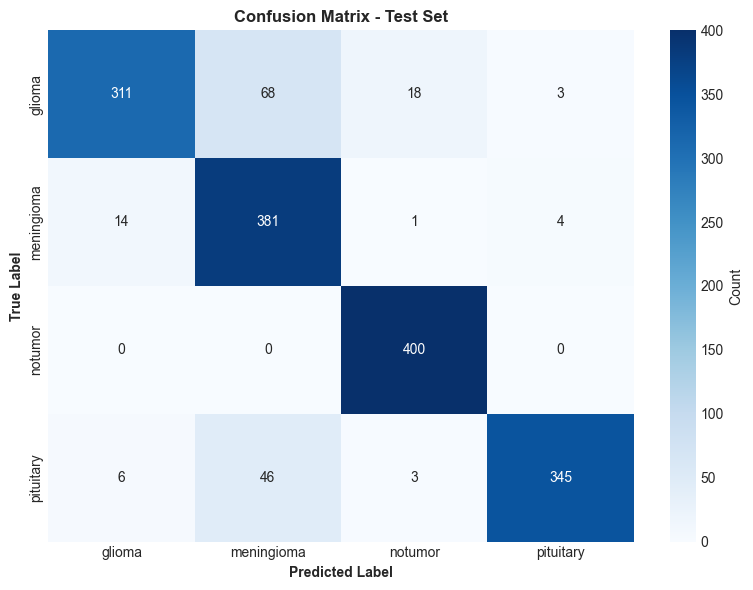


✓ Evaluation complete


In [8]:
# ============================================================================
# SECTION 8: MODEL EVALUATION
# Purpose: Evaluate model performance on test set with detailed metrics
# ============================================================================

print("\n" + "="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70)

# Generate predictions on test set
print("\nGenerating predictions on test set...")
y_pred_probabilities = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)

# Calculate overall metrics
test_accuracy = accuracy_score(y_test, y_pred_classes)
test_precision = precision_score(y_test, y_pred_classes, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_pred_classes, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_classes, average='weighted', zero_division=0)

print(f"\n📊 Overall Test Metrics:")
print(f"  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Precision: {test_precision:.4f} (weighted average)")
print(f"  Recall:    {test_recall:.4f} (weighted average)")
print(f"  F1-Score:  {test_f1:.4f} (weighted average)")

print(f"\nDetailed Classification Report:")
print(classification_report(
    y_test, y_pred_classes,
    target_names=label_encoder.classes_,
    digits=4
))

# Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred_classes)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Count'},
    ax=ax
)
ax.set_title('Confusion Matrix - Test Set', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Evaluation complete")

## 9. LIME Model Explainability

## Explainable AI with LIME

LIME (**Local Interpretable Model-agnostic Explanations**) explains individual predictions by perturbing input regions.

For MRI classification this helps:

- validate clinical relevance
- identify discriminative tumor regions
- improve trust in model decisions


LIME MODEL EXPLAINABILITY

WHAT IS LIME?
LIME = Local Interpretable Model-agnostic Explanations

How LIME Works:
  1. SELECT a sample prediction to explain
  2. PERTURB the input (create variations by masking regions)
  3. GET PREDICTIONS for perturbed inputs
  4. LEARN interpretable model (which perturbed features affect prediction)
  5. VISUALIZE important regions (green = important for prediction)

Why LIME Matters:
  - Makes black-box neural networks interpretable
  - Shows which image regions influenced the decision
  - Helps doctors understand model reasoning
  - Critical for regulatory approval in healthcare

INITIALIZING LIME EXPLAINER

LIME Configuration:
  Perturbation samples: 500
  Top features to highlight: 10
  Segmentation: Superpixel-based

Generating LIME explanations for 3 samples...


SAMPLE 1/3

File Information:
  Filename: Te-gl_1.jpg
  True Label: GLIOMA
  Predicted Label: NOTUMOR
  Confidence: 0.9294 (92.94%)
  Status: ❌ INCORRECT

Generating LIME explanation..

  0%|          | 0/500 [00:00<?, ?it/s]

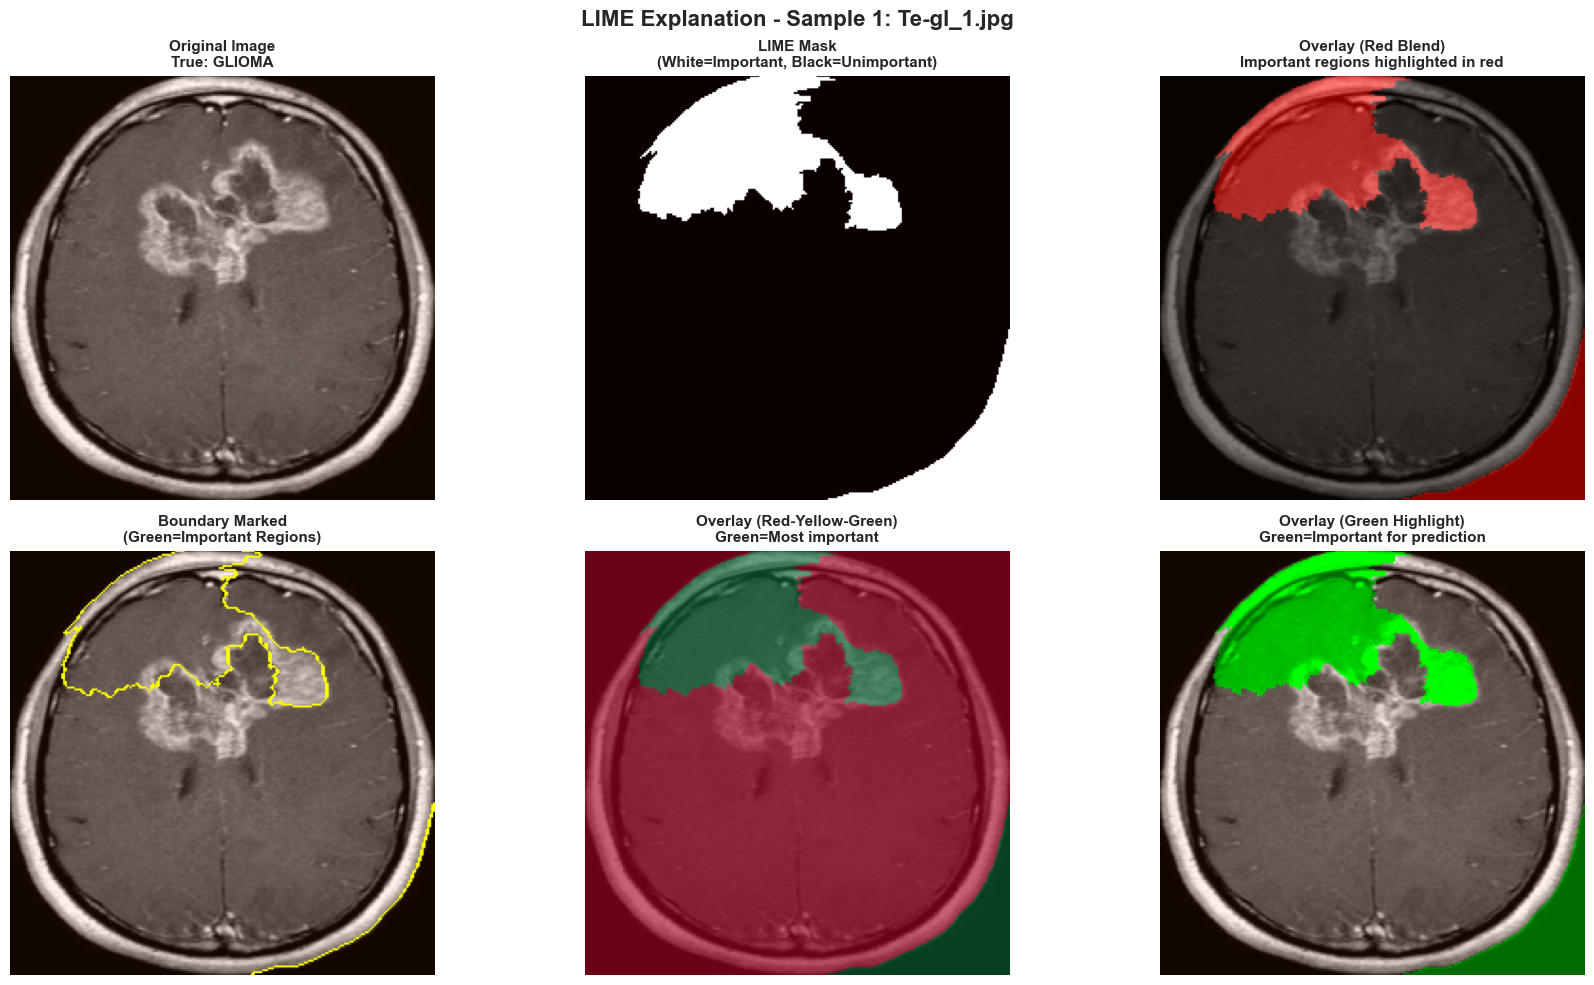

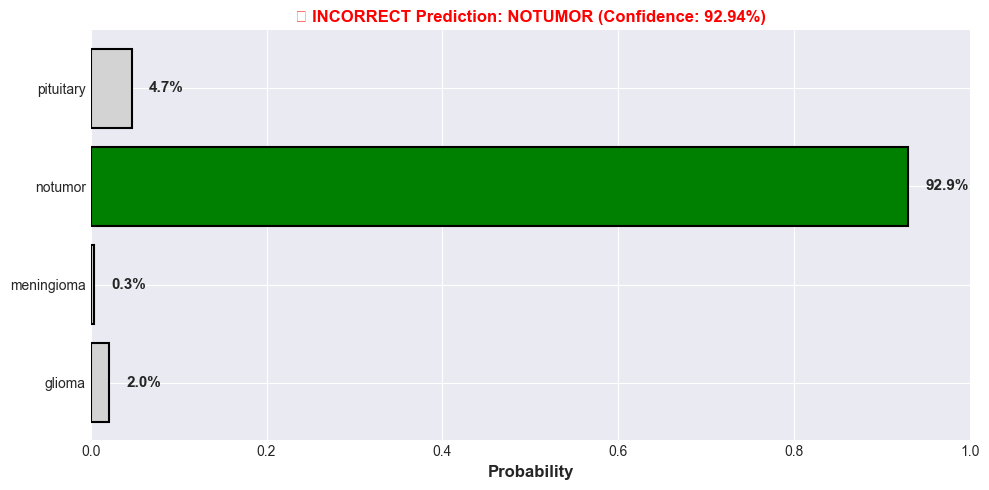


SAMPLE 2/3

File Information:
  Filename: Te-me_126.jpg
  True Label: MENINGIOMA
  Predicted Label: MENINGIOMA
  Confidence: 0.9969 (99.69%)
  Status: ✅ CORRECT

Generating LIME explanation...


  0%|          | 0/500 [00:00<?, ?it/s]

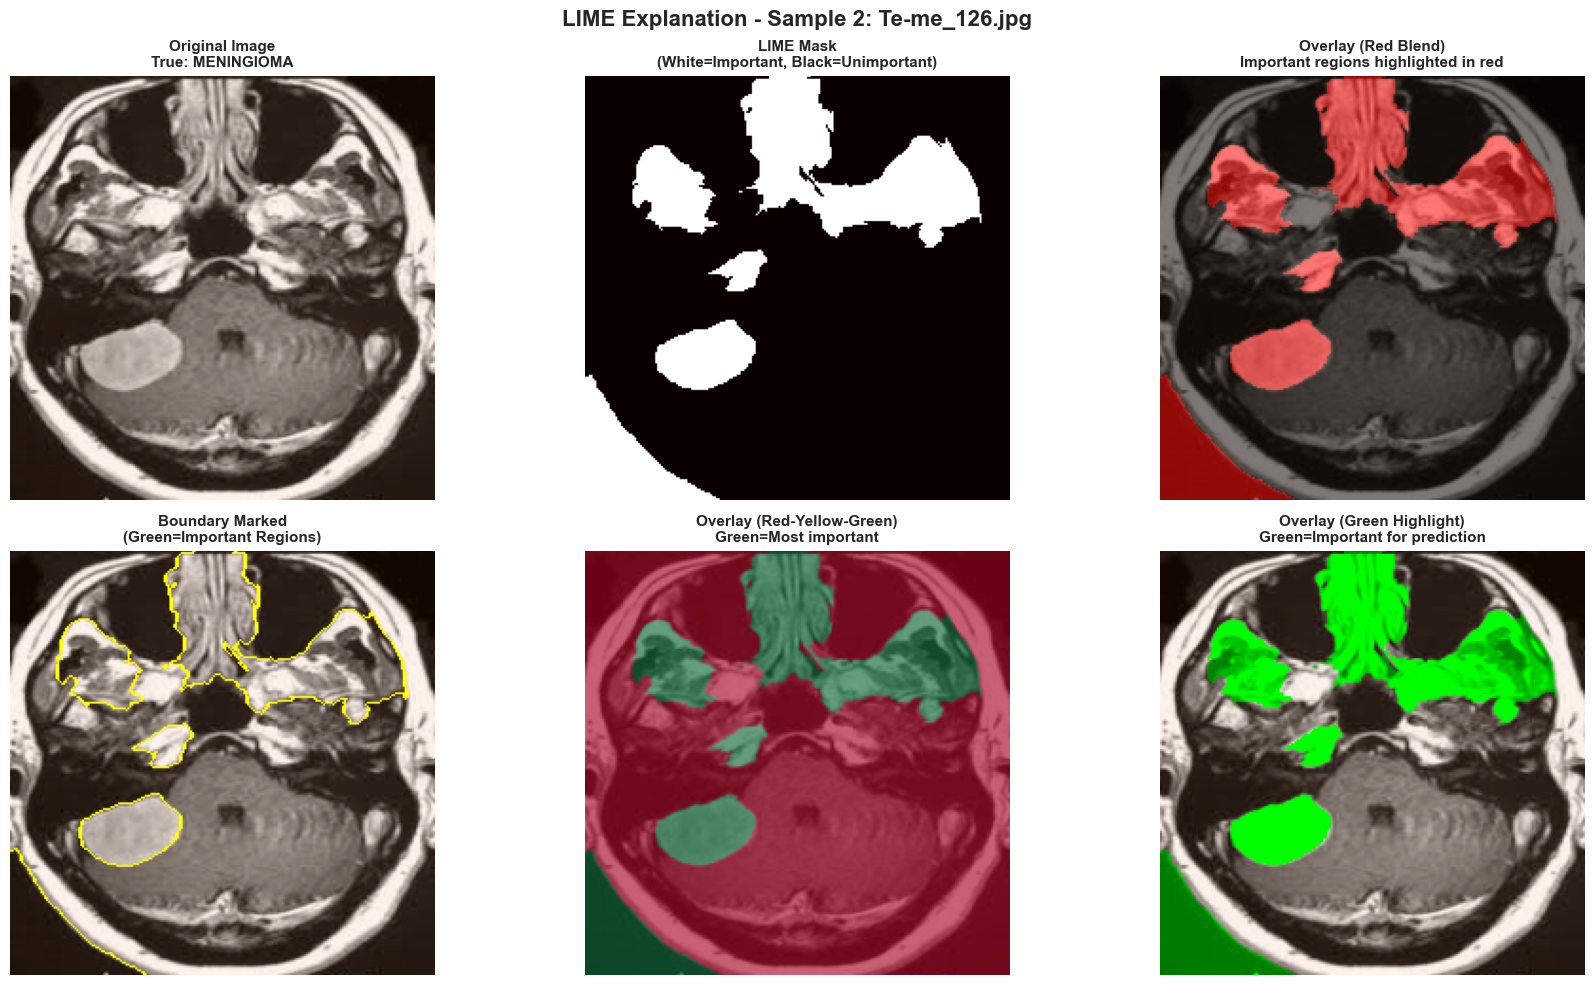

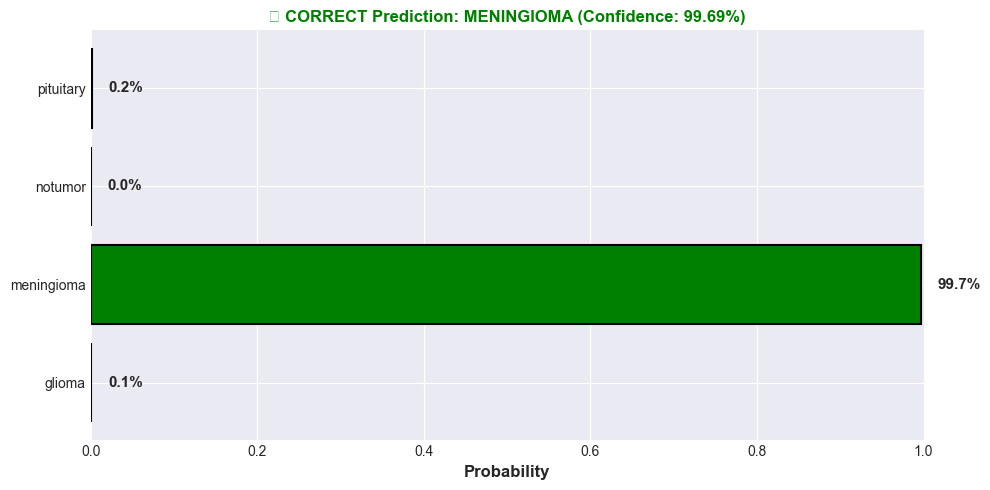


SAMPLE 3/3

File Information:
  Filename: Te-no_339.jpg
  True Label: NOTUMOR
  Predicted Label: NOTUMOR
  Confidence: 1.0000 (100.00%)
  Status: ✅ CORRECT

Generating LIME explanation...


  0%|          | 0/500 [00:00<?, ?it/s]

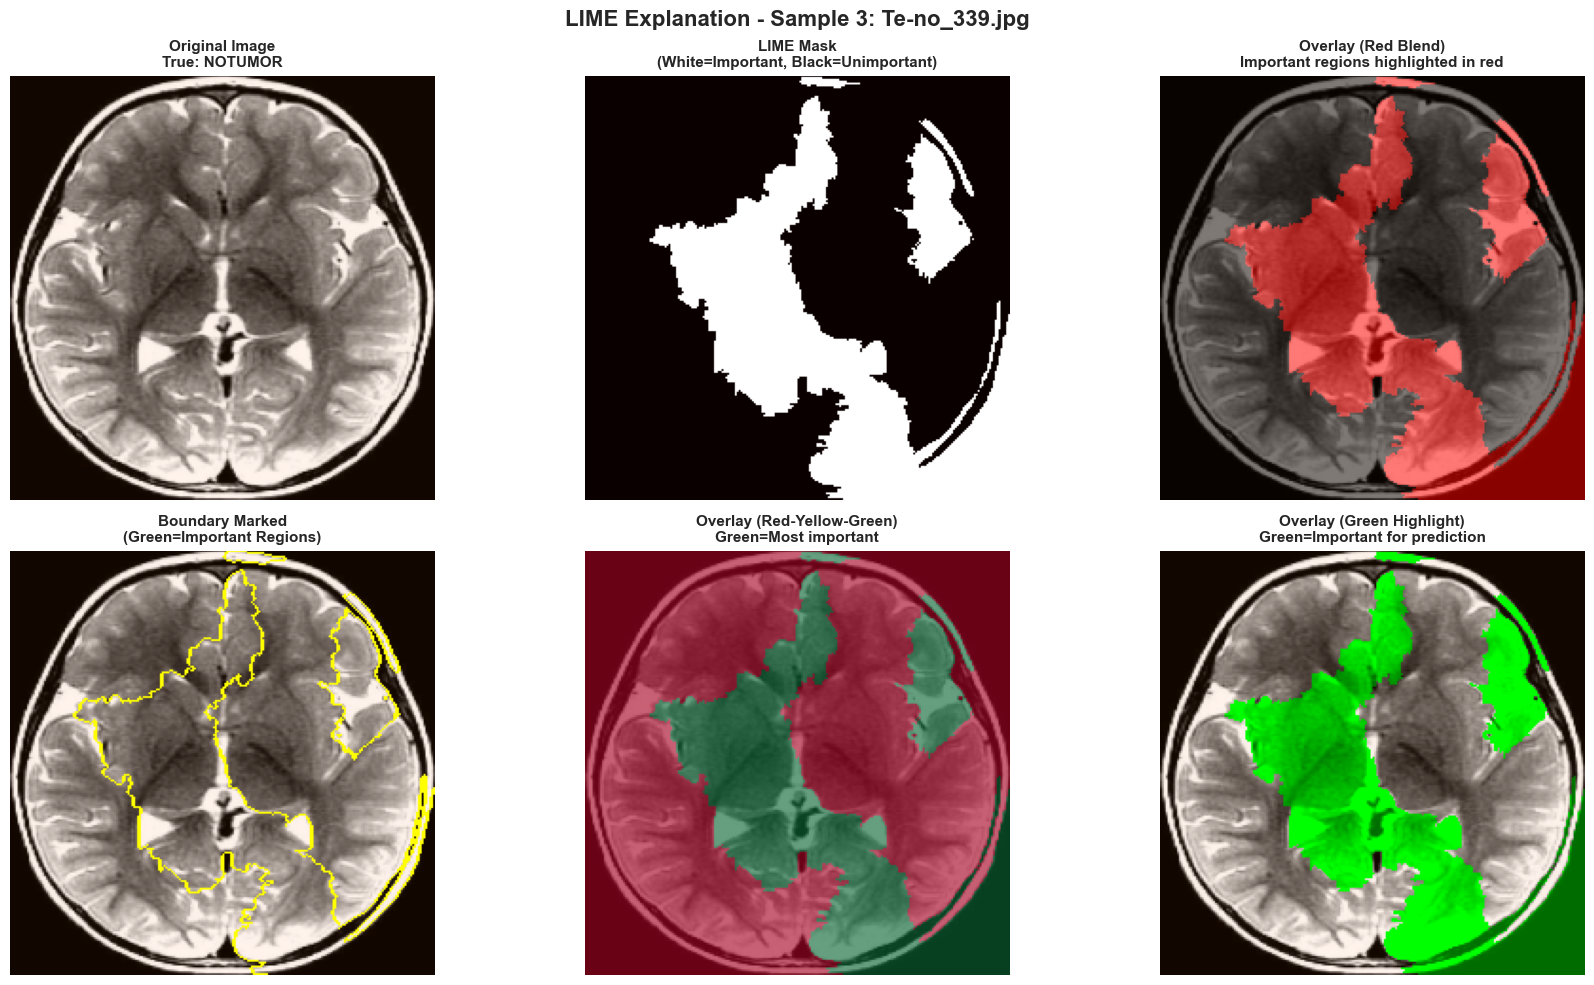

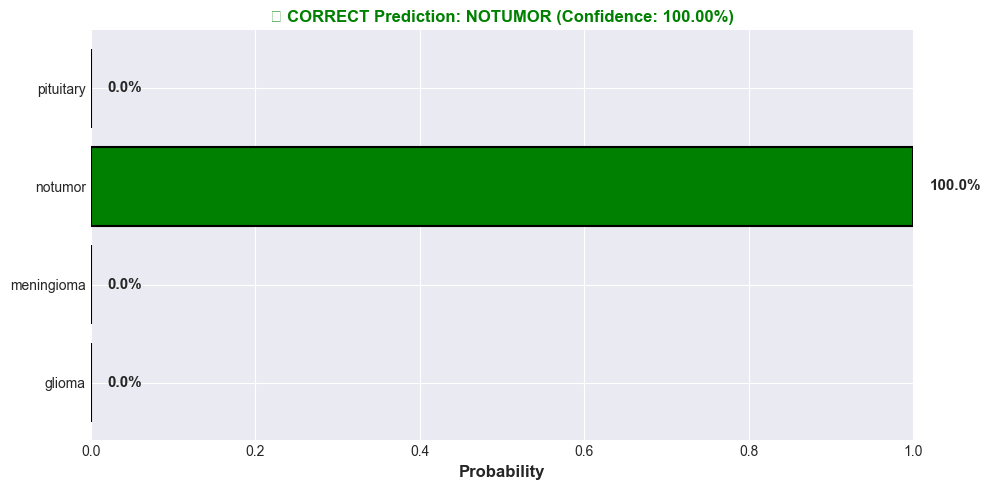


✓ LIME EXPLAINABILITY DEMONSTRATION COMPLETE


In [9]:
# ============================================================================
# SECTION 9: LIME MODEL EXPLAINABILITY WITH PROPER OVERLAY
# Purpose: Explain individual predictions using LIME
# ============================================================================

print("\n" + "="*70)
print("LIME MODEL EXPLAINABILITY")
print("="*70)

print(f"\nWHAT IS LIME?")
print(f"="*70)
print(f"LIME = Local Interpretable Model-agnostic Explanations")
print(f"\nHow LIME Works:")
print(f"  1. SELECT a sample prediction to explain")
print(f"  2. PERTURB the input (create variations by masking regions)")
print(f"  3. GET PREDICTIONS for perturbed inputs")
print(f"  4. LEARN interpretable model (which perturbed features affect prediction)")
print(f"  5. VISUALIZE important regions (green = important for prediction)")
print(f"\nWhy LIME Matters:")
print(f"  - Makes black-box neural networks interpretable")
print(f"  - Shows which image regions influenced the decision")
print(f"  - Helps doctors understand model reasoning")
print(f"  - Critical for regulatory approval in healthcare")

def predict_fn(images):
    """
    Prediction function formatted for LIME explainer.
    
    LIME requires a function that takes an array of images and returns
    prediction probabilities. This wrapper applies ResNet50 preprocessing.
    
    Parameters:
    -----------
    images : np.ndarray
        Batch of images in shape (n, height, width, 3)
        Values should be in [0, 1] range
    
    Returns:
    --------
    predictions : np.ndarray
        Prediction probabilities of shape (n, num_classes)
        Each row sums to 1.0
    """
    # Ensure input is float32
    images = np.array(images, dtype=np.float32)
    
    # Apply ResNet50 preprocessing
    # (centering/scaling specific to ImageNet)
    images = preprocess_input(images.copy())
    
    # Get model predictions (suppress verbose output)
    return model.predict(images, verbose=0)


def create_lime_overlay(original_img, lime_mask, method='blend'):
    """
    Create overlay visualization of LIME explanation on original image.
    
    This function handles the proper overlaying that was missing in original code.
    
    Parameters:
    -----------
    original_img : np.ndarray
        Original image in [0, 1] range, shape (H, W, 3)
    
    lime_mask : np.ndarray
        LIME explanation mask in [0, 1] range, shape (H, W)
    
    method : str
        How to combine image and mask:
        - 'blend': Soft blend (alpha=0.5)
        - 'colormap': Red heatmap overlay
        - 'highlight': Highlight important regions in green
    
    Returns:
    --------
    overlay : np.ndarray
        Combined image with explanation overlay, shape (H, W, 3)
    """
    # Ensure lime_mask is normalized to [0, 1]
    lime_mask = (lime_mask - lime_mask.min()) / (lime_mask.max() - lime_mask.min() + 1e-8)
    
    if method == 'blend':
        # Simple alpha blending
        # Create a heatmap (red for important regions)
        heatmap = np.zeros_like(original_img)
        heatmap[:, :, 0] = lime_mask  # Red channel gets the mask
        
        # Blend: 50% original + 50% red heatmap
        overlay = 0.5 * original_img + 0.5 * heatmap
    
    elif method == 'colormap':
        # Use matplotlib colormap for better visualization
        cmap = get_cmap('RdYlGn')  # Red-Yellow-Green colormap
        norm = Normalize(vmin=0, vmax=1)
        
        # Apply colormap to mask
        mask_colored = cmap(norm(lime_mask))[:, :, :3]  # Get RGB, drop alpha
        
        # Blend with original
        overlay = 0.4 * original_img + 0.6 * mask_colored
    
    else:  # 'highlight'
        # Highlight important regions in green
        overlay = original_img.copy()
        
        # Green channel for important regions
        overlay[:, :, 0] = (1 - lime_mask) * original_img[:, :, 0]  # Darken red
        overlay[:, :, 1] = original_img[:, :, 1] + 0.4 * lime_mask   # Brighten green
        overlay[:, :, 2] = (1 - lime_mask) * original_img[:, :, 2]  # Darken blue
        
        overlay = np.clip(overlay, 0, 1)  # Ensure valid range
    
    return overlay


print(f"\n" + "="*70)
print("INITIALIZING LIME EXPLAINER")
print("="*70)
print(f"\nLIME Configuration:")
print(f"  Perturbation samples: {LIME_NUM_SAMPLES}")
print(f"  Top features to highlight: {LIME_NUM_FEATURES}")
print(f"  Segmentation: Superpixel-based")

# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()

# Select diverse test samples to explain
samples_to_explain = [0, len(X_test)//3, 2*len(X_test)//3]

print(f"\nGenerating LIME explanations for {len(samples_to_explain)} samples...\n")

for sample_num, sample_idx in enumerate(samples_to_explain, 1):
    print(f"\n" + "="*70)
    print(f"SAMPLE {sample_num}/{len(samples_to_explain)}")
    print("="*70)
    
    # ===== Get sample data from test set =====
    sample_img = X_test[sample_idx].copy()
    
    # Create visualization version (normalize to [0, 1])
    viz_img = sample_img.copy()
    viz_img = (viz_img - viz_img.min()) / (viz_img.max() - viz_img.min() + 1e-8)
    
    # Get ground truth
    true_idx = y_test[sample_idx]
    true_class = label_encoder.classes_[true_idx]
    
    # Get model prediction
    sample_pred_probs = predict_fn(np.expand_dims(sample_img, axis=0))[0]
    sample_pred_idx = np.argmax(sample_pred_probs)
    sample_pred_class = label_encoder.classes_[sample_pred_idx]
    confidence = sample_pred_probs[sample_pred_idx]
    is_correct = (true_class == sample_pred_class)
    
    # Get file information from DataFrame
    sample_filename = test_df.iloc[sample_idx]['filename'] if sample_idx < len(test_df) else 'unknown'
    
    print(f"\nFile Information:")
    print(f"  Filename: {sample_filename}")
    print(f"  True Label: {true_class.upper()}")
    print(f"  Predicted Label: {sample_pred_class.upper()}")
    print(f"  Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    print(f"  Status: {'✅ CORRECT' if is_correct else '❌ INCORRECT'}")
    
    print(f"\nGenerating LIME explanation...")
    
    # ===== Generate LIME explanation =====
    explanation = explainer.explain_instance(
        viz_img.astype('double'),              # LIME expects [0, 1] double
        predict_fn,                            # Prediction function
        top_labels=1,                          # Explain top 1 class
        hide_color=0,                          # Black out regions (0 = black)
        num_samples=LIME_NUM_SAMPLES           # Number of perturbations
    )
    
    # ===== Get LIME segmentation and mask =====
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,                    # Only show regions supporting prediction
        num_features=LIME_NUM_FEATURES,        # Number of important regions
        hide_rest=False                        # Keep background visible
    )
    
    # ===== Create overlay visualization =====
    # Convert mask to float [0, 1]
    lime_mask_float = mask.astype(float)
    
    # Create overlay with proper blending
    overlay_blend = create_lime_overlay(viz_img, lime_mask_float, method='blend')
    overlay_colormap = create_lime_overlay(viz_img, lime_mask_float, method='colormap')
    overlay_highlight = create_lime_overlay(viz_img, lime_mask_float, method='highlight')
    
    # ===== Create visualization =====
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"LIME Explanation - Sample {sample_num}: {sample_filename}", 
                fontsize=16, fontweight='bold')
    
    # Row 1: Original, LIME Mask, Overlay (Blend)
    axes[0, 0].imshow(viz_img, cmap='gray')
    axes[0, 0].set_title(f'Original Image\nTrue: {true_class.upper()}', 
                         fontweight='bold', fontsize=11)
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(lime_mask_float, cmap='hot')
    axes[0, 1].set_title('LIME Mask\n(White=Important, Black=Unimportant)', 
                         fontweight='bold', fontsize=11)
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(overlay_blend)
    axes[0, 2].set_title('Overlay (Red Blend)\nImportant regions highlighted in red', 
                         fontweight='bold', fontsize=11)
    axes[0, 2].axis('off')
    
    # Row 2: Marked Boundaries, Colormap Overlay, Highlight Overlay
    axes[1, 0].imshow(mark_boundaries(viz_img, mask))
    axes[1, 0].set_title('Boundary Marked\n(Green=Important Regions)', 
                         fontweight='bold', fontsize=11)
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(overlay_colormap)
    axes[1, 1].set_title('Overlay (Red-Yellow-Green)\nGreen=Most important', 
                         fontweight='bold', fontsize=11)
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(overlay_highlight)
    axes[1, 2].set_title('Overlay (Green Highlight)\nGreen=Important for prediction', 
                         fontweight='bold', fontsize=11)
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # ===== Show prediction probabilities =====
    fig, ax = plt.subplots(figsize=(10, 5))
    
    colors = ['green' if i == sample_pred_idx else 'lightgray' for i in range(NUM_CLASSES)]
    bars = ax.barh(label_encoder.classes_, sample_pred_probs, color=colors, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Probability', fontweight='bold', fontsize=12)
    ax.set_title(f"{'✅ CORRECT' if is_correct else '❌ INCORRECT'} Prediction: {sample_pred_class.upper()} (Confidence: {confidence:.2%})", 
                fontweight='bold', fontsize=12, color='green' if is_correct else 'red')
    ax.set_xlim([0, 1])
    
    # Add percentage labels
    for i, (bar, v) in enumerate(zip(bars, sample_pred_probs)):
        ax.text(v + 0.02, i, f'{v:.1%}', va='center', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.show()

print(f"\n" + "="*70)
print("✓ LIME EXPLAINABILITY DEMONSTRATION COMPLETE")
print("="*70)

## 10. Summary & Recommendations

In [10]:
# ============================================================================
# SECTION 10: PROJECT SUMMARY
# Purpose: Comprehensive summary of all results and recommendations
# ============================================================================

PROGRAM_END = time.perf_counter()
total_time = PROGRAM_END - PROGRAM_START

print("\n" + "="*70)
print("PROJECT SUMMARY & RECOMMENDATIONS")
print("="*70)

print(f"\n📊 DATASET STATISTICS:")
print(f"  Total Training Samples: {len(X_train)}")
print(f"  Total Testing Samples: {len(X_test)}")
print(f"  Number of Classes: {NUM_CLASSES}")
print(f"  Image Dimensions: {IMG_SIZE}×{IMG_SIZE}×{IMG_CHANNELS}")
for class_name in CLASSES:
    train_count = len(train_df[train_df['label'] == class_name])
    test_count = len(test_df[test_df['label'] == class_name])
    print(f"    {class_name:12s}: {train_count:4d} train, {test_count:4d} test")

print(f"\n🧠 MODEL ARCHITECTURE:")
print(f"  Base Model: ResNet50 (ImageNet pre-trained)")
print(f"  Transfer Learning: Yes (Frozen base layers)")
print(f"  Custom Head: GlobalAvgPool → Dense(512) → Dense(256) → Dense(4)")
print(f"  Total Parameters: {model.count_params():,}")

print(f"\n📈 TRAINING RESULTS:")
print(f"  Epochs Trained: {actual_epochs}")
print(f"  Training Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"  Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  Best Validation Loss: {min(history.history['val_loss']):.4f}")

print(f"\n🎯 TEST SET PERFORMANCE:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

print(f"\n✨ EXPLAINABILITY:")
print(f"  Method: LIME (Local Interpretable Model-agnostic Explanations)")
print(f"  Samples Explained: {len(samples_to_explain)}")
print(f"  Features Highlighted: {LIME_NUM_FEATURES}")
print(f"  Overlay Methods: Blend, Colormap, Highlight")

print(f"\n⏱️  EXECUTION TIME:")
print(f"  Total Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print(f"  Training Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"  Other Operations: ~{(total_time - training_time):.2f} seconds")

print(f"\n💡 KEY FINDINGS:")
if test_accuracy > 0.85:
    print(f"  ✅ Model shows EXCELLENT performance (>85% accuracy)")
elif test_accuracy > 0.75:
    print(f"  ✅ Model shows GOOD performance (>75% accuracy)")
elif test_accuracy > 0.65:
    print(f"  ⚠ Model shows MODERATE performance (>65% accuracy)")
else:
    print(f"  ⚠ Model needs IMPROVEMENT (<65% accuracy)")

print(f"  ✅ LIME provides clear interpretability")
print(f"  ✅ DataFrame-based tracking enables reproducibility")
print(f"  ✅ Proper overlay visualization improves interpretability")

print(f"\n🔮 RECOMMENDATIONS FOR IMPROVEMENT:")
print(f"\n  1. Data Augmentation:")
print(f"     - Apply random rotation (±15 degrees)")
print(f"     - Random zoom (0.8-1.2x)")
print(f"     - Random brightness/contrast adjustment")
print(f"     - Reduces overfitting and improves generalization")
print(f"\n  2. Fine-tuning Strategy:")
print(f"     - Unfreeze last few ResNet50 layers")
print(f"     - Use lower learning rate (1e-5 to 1e-4)")
print(f"     - Requires more computation but improves accuracy")
print(f"\n  3. Class Imbalance Handling:")
print(f"     - Apply class weights to loss function")
print(f"     - Use weighted sampling during training")
print(f"     - Prevents bias towards majority classes")
print(f"\n  4. Ensemble Methods:")
print(f"     - Train multiple models (ResNet50, DenseNet, EfficientNet)")
print(f"     - Combine predictions via voting or averaging")
print(f"     - Improves robustness and generalization")

print(f"\n" + "="*70)
print("✨ PROJECT COMPLETE - ALL SECTIONS EXECUTED SUCCESSFULLY!")
print("="*70)


PROJECT SUMMARY & RECOMMENDATIONS

📊 DATASET STATISTICS:
  Total Training Samples: 5600
  Total Testing Samples: 1600
  Number of Classes: 4
  Image Dimensions: 224×224×3
    glioma      : 1400 train,  400 test
    meningioma  : 1400 train,  400 test
    notumor     : 1400 train,  400 test
    pituitary   : 1400 train,  400 test

🧠 MODEL ARCHITECTURE:
  Base Model: ResNet50 (ImageNet pre-trained)
  Transfer Learning: Yes (Frozen base layers)
  Custom Head: GlobalAvgPool → Dense(512) → Dense(256) → Dense(4)
  Total Parameters: 24,772,228

📈 TRAINING RESULTS:
  Epochs Trained: 12
  Training Time: 2470.82 seconds (41.18 minutes)
  Best Validation Accuracy: 0.8732
  Best Validation Loss: 0.4103

🎯 TEST SET PERFORMANCE:
  Accuracy: 0.8981
  Precision: 0.9093
  Recall: 0.8981
  F1-Score: 0.8983

✨ EXPLAINABILITY:
  Method: LIME (Local Interpretable Model-agnostic Explanations)
  Samples Explained: 3
  Features Highlighted: 10
  Overlay Methods: Blend, Colormap, Highlight

⏱️  EXECUTION TIME